# Exploratory Data Analysis Churn Analysis


###### https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Import Library

Proses memuat fungsi-fungsi dan modul-modul (packages) ke dalam suatu program. Dengan memuat library, kita dapat menggunakan berbagai fungsi dan objek yang telah dibuat sebelumnya. Hal ini dapat mempercepat dan memudahkan proses pengembangan program, karena tidak perlu membuat ulang fungsi atau objek yang sudah ada.

In [ ]:
import pandas as pd # Import library pandas untuk analisis data
import numpy as np # Import library numpy untuk membentuk dan memanipulasi arrays dan berfokus pada scientific computing
import seaborn as sns # Import library seaborn untuk membuat visualisasi yang lebih “high level” dari segi interface dan statistical graphics
import matplotlib.pyplot as plt # Import library matplotlib.pyplot untuk mendukung berbagai jenis gambar visualisasi data
from scipy.stats import skew, kurtosis # Import library SciPy untuk melakukan analisis statistik

#Pandas show all column
pd.set_option('display.max_columns', 200) # Untuk mengatur opsi tampilan pada pandas dataframe agar menampilkan semua kolom dalam dataframe hingga 200 kolom

import warnings # Import library warnings untuk mengendalikan perilaku warning atau pesan peringatan saat menjalankan program
warnings.filterwarnings("ignore") # Untuk mengabaikan semua peringatan (warnings) yang muncul selama menjalankan program sehingga tidak mengganggu tampilan hasil analisis data

# Load Dataset

Proses membaca dan mengimpor data dari suatu sumber ke dalam suatu program. Dataset adalah kumpulan data yang diambil dari sumber tertentu dan digunakan untuk tujuan analisis atau pemodelan. Dataset yang dimaksud adalah "Telco Customer Churn" yang tersedia di platform Kaggle. Dataset ini berisi tentang informasi pelanggan sebuah perusahaan telekomunikasi (telco) fiktif dan apakah mereka berhenti menggunakan layanan (churn) atau tidak.

In [ ]:
# Fungsi pd.read_csv() untuk memuat dataset file csv dari sumber eksternal menggunakan tautan yang disediakan dan membuat dataframe pandas
df = pd.read_csv("https://raw.githubusercontent.com/ferryatm/telcocustomerchurn/main/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Data Understanding

Tahap awal dalam proses data mining yang bertujuan untuk memahami karakteristik dan struktur dari data yang akan digunakan dalam analisis atau pemodelan. Tujuan utama dari tahap ini adalah untuk mendapatkan pemahaman yang baik tentang data yang tersedia, termasuk jenis data, jumlah data, distribusi data, dan kualitas data.

In [ ]:
df.head() # Metode df.head() untuk menampilkan lima baris pertama dari dataframe

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape # Metode df.shape untuk mengetahui dimensi atau baris dan kolom dari dataframe

(7043, 21)

Dataset "Telco Customer Churn" yang disediakan di Kaggle ini terdiri dari 7.043 baris dan 21 kolom, dengan tipe data yang berbeda-beda. Dataset ini berisi data mengenai churn pelanggan layanan telekomunikasi, yang mencakup informasi mengenai profil pelanggan, layanan yang digunakan, tagihan, dan sebagainya.

In [ ]:
df.columns # Metode df.columns untuk mengetahui nama kolom atau variabel pada dataset

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Berikut adalah daftar kolom pada dataset Telco Customer Churn:
* customerID: ID unik pelanggan
* gender: jenis kelamin pelanggan (Male/Female)
* SeniorCitizen: apakah pelanggan tersebut merupakan warga lanjut usia atau tidak (1/0)
* Partner: apakah pelanggan tersebut memiliki pasangan atau tidak (Yes/No)
* Dependents: apakah pelanggan tersebut memiliki tanggungan atau tidak (Yes/No)
* tenure: jumlah bulan pelanggan telah menggunakan layanan
* PhoneService: apakah pelanggan menggunakan layanan telepon atau tidak (Yes/No)
* MultipleLines: apakah pelanggan menggunakan beberapa saluran atau tidak (Yes/No/No phone service)
* InternetService: jenis layanan internet yang digunakan oleh pelanggan (DSL/Fiber optic/No)
* OnlineSecurity: apakah pelanggan menggunakan layanan keamanan online atau tidak (Yes/No/No internet service)
* OnlineBackup: apakah pelanggan menggunakan layanan cadangan online atau tidak (Yes/No/No internet service)
* DeviceProtection: apakah pelanggan menggunakan layanan perlindungan perangkat atau tidak (Yes/No/No internet service)
* TechSupport: apakah pelanggan menggunakan layanan dukungan teknis atau tidak (Yes/No/No internet service)
* StreamingTV: apakah pelanggan menggunakan layanan streaming TV atau tidak (Yes/No/No internet service)
* StreamingMovies: apakah pelanggan menggunakan layanan streaming film atau tidak (Yes/No/No internet service)
* Contract: jenis kontrak layanan (Month-to-month/One year/Two year)
* PaperlessBilling: apakah pelanggan menggunakan tagihan tanpa kertas atau tidak (Yes/No)
* PaymentMethod: metode pembayaran yang digunakan oleh pelanggan (Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic))
* MonthlyCharges: biaya bulanan pelanggan dalam dollar
* TotalCharges: total biaya yang dibebankan pada pelanggan
* Churn: apakah pelanggan tersebut berhenti menggunakan layanan atau tidak (Yes/No)

### Check Unique Values of Each Column

Proses untuk melihat nilai unik yang terdapat pada setiap kolom dalam dataset. Hal ini berguna untuk memahami jenis data yang terdapat pada setiap kolom, termasuk apakah kolom tersebut termasuk ke dalam variabel numerik atau kategorikal. Dengan melakukan proses ini, kita dapat memperoleh informasi tentang nilai unik pada setiap kolom dalam dataset, termasuk jumlah nilai unik, jenis data pada setiap kolom, dan adanya nilai yang hilang atau tidak sesuai pada setiap kolom.

In [ ]:
for column in df.columns: # for column in df.columns adalah loop untuk setiap kolom pada dataset
    print('Column: {} - Unique Values: {}'.format(column, df[column].unique())) # df[column].unique() adalah metode untuk mendapatkan nilai unik dari kolom yang diiterasi

Column: customerID - Unique Values: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
Column: gender - Unique Values: ['Female' 'Male']
Column: SeniorCitizen - Unique Values: [0 1]
Column: Partner - Unique Values: ['Yes' 'No']
Column: Dependents - Unique Values: ['No' 'Yes']
Column: tenure - Unique Values: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Column: PhoneService - Unique Values: ['No' 'Yes']
Column: MultipleLines - Unique Values: ['No phone service' 'No' 'Yes']
Column: InternetService - Unique Values: ['DSL' 'Fiber optic' 'No']
Column: OnlineSecurity - Unique Values: ['No' 'Yes' 'No internet service']
Column: OnlineBackup - Unique Values: ['Yes' 'No' 'No internet service']
Column: DeviceProtection - Unique Values: ['No' 'Yes' 'No internet service']
Column: TechSuppor

Dengan mencetak nilai unik dari setiap kolom, kita dapat mengecek apakah terdapat nilai yang tidak masuk akal atau mungkin memerlukan perhatian lebih lanjut. Misalnya, jika sebuah kolom bernilai "Yes" atau "No", tetapi ada nilai "Maybe", maka kemungkinan ada kesalahan dalam pengisian data. Atau jika sebuah kolom bernilai numerik, namun memiliki nilai yang tidak masuk akal, seperti nilai negatif atau angka yang jauh diluar rentang nilai yang diharapkan, maka hal ini bisa menjadi petunjuk untuk melakukan pengecekan kembali pada data yang diberikan. Dalam hal ini, kode tersebut membantu dalam memeriksa data sebelum melakukan analisis lebih lanjut dan membantu memastikan kualitas data yang akan digunakan.

### Statistical Information and Description

Proses untuk memberikan informasi deskriptif dan statistik tentang data yang digunakan dalam analisis atau pemodelan. Hal ini dapat membantu memahami karakteristik dan distribusi data, termasuk nilai rata-rata, median, standar deviasi, nilai maksimum dan minimum, dll.

In [ ]:
df.info() # Metode df.info() untuk mengetahui bentuk tipe objek dari data
df.describe() # Metode df.describe() untuk mengetahui ringkasan statistik kolom numerik dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Terdapat 7043 pelanggan dalam data ini.
* Untuk kolom tenure, rata-rata masa berlangganan pelanggan adalah 32 bulan dengan paling sebentar adalah 0 bulan dan paling lama 72 bulan.

* Untuk kolom MonthlyCharges, rata-rata pelanggan menghabiskan biaya 64.76 USD/bulan dengan paling murah adalah 18.25 USD/bulan dan paling mahal 118.75 USD/bulan.

* Untuk kolom TotalCharges, rata-rata pelanggan menghabiskan 2279.58 USD dengan paling murahnya adalah 0 USD (karena ada yang berlangganan hanya 0 bulan jadi saat dikalikan dengan MonthlyCharges menjadi 0 USD) dan paling mahalnya adalah 8550 USD.

Yang perlu diperhatikan:
- Apakah ada data dengan tipe yang kurang sesuai? Misal, Name dengan tipe int64
- Apakah ada data yang hilang? Cari kolom dengan count < jumlah row

### Drop customerID Column

Kolom customerID hanya merupakan identifier atau pengenal unik dari setiap data pelanggan, dan tidak memberikan informasi yang relevan atau nilai tambah dalam analisis data, maka dapat dipertimbangkan untuk dihapus dari dataset.

In [ ]:
df = df.drop(['customerID'], axis=1) # Metode 'drop()' dengan axis 1 digunakan untuk menghapus kolom dari dataframe

### Change Data Type

Pada dataset, kolom "TotalCharges" seharusnya berisi nilai numerik untuk setiap baris. Namun, pada beberapa baris, kolom "TotalCharges" diisi dengan nilai kosong yang direpresentasikan sebagai spasi. Untuk memproses dataset ini, kita perlu mengubah nilai kosong tersebut menjadi nilai NaN agar dapat diidentifikasi sebagai missing value dan dapat ditangani secara tepat. Selain itu, tipe data SeniorCitizen diubah menjadi object untuk memudahkan pemahaman dalam interpretasi data serta merupakan data kategorik

In [ ]:
# Mengubah nilai kosong (yang dalam dataset ini direpresentasikan sebagai spasi) pada kolom "TotalCharges" menjadi nilai NaN (Not a Number)
df['TotalCharges'] = df['TotalCharges'].apply(lambda x: np.nan if x == ' ' else float(x))

# Mengganti tipe data SeniorCitizen menjadi object
df['SeniorCitizen']=df['SeniorCitizen'].astype('O')

Syntax df['TotalCharges'].apply(lambda x: np.nan if x == ' ' else float(x)) digunakan untuk mengubah nilai kosong menjadi NaN dengan cara membuat sebuah fungsi anonim (lambda) yang mengganti nilai kosong dengan NaN dan mengonversi nilai numerik ke tipe data float. Metode .apply() digunakan untuk menerapkan fungsi ini pada setiap elemen pada kolom "TotalCharges".

Setelah syntax ini dijalankan, kita dapat memastikan bahwa tidak ada lagi nilai kosong pada kolom "TotalCharges" sehingga dapat dilanjutkan ke proses missing value checking

### Missing Value Checking

Proses untuk memeriksa adanya nilai yang hilang atau kosong pada dataset. Hal ini penting karena keberadaan nilai yang hilang dapat mempengaruhi analisis atau pemodelan yang dilakukan dan dapat menyebabkan kesalahan dalam hasil akhir.

In [ ]:
print(df.count() < len(df)) # Untuk menunjukkan apakah setiap kolom memiliki jumlah nilai yang sama dengan jumlah baris dalam dataset atau tidak

gender              False
SeniorCitizen       False
Partner             False
Dependents          False
tenure              False
PhoneService        False
MultipleLines       False
InternetService     False
OnlineSecurity      False
OnlineBackup        False
DeviceProtection    False
TechSupport         False
StreamingTV         False
StreamingMovies     False
Contract            False
PaperlessBilling    False
PaymentMethod       False
MonthlyCharges      False
TotalCharges         True
Churn               False
dtype: bool


Jika ada kolom yang memiliki nilai yang kurang dari jumlah baris, maka nilai tersebut akan dianggap sebagai True, sementara yang memiliki nilai yang sama dari jumlah baris akan dianggap False.

Dapat dilihat bahwa kolom "TotalCharges" memiliki nilai yang kurang dari jumlah baris sehingga nilai tersebut akan dianggap sebagai True.

In [ ]:
# Mencari jumlah missing value pada setiap variabel
mv_df = df.isnull().sum() # Metode .isnull() untuk mengembalikan DataFrame dengan nilai boolean yang menunjukkan apakah setiap sel hilang atau tidak.
                          # Metode .sum() untuk menghitung jumlah nilai yang hilang di setiap kolom DataFrame
print(mv_df)
print(mv_df / len(df) * 100) # Persentase missing value pada setiap variabel

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
gender              0.000000
SeniorCitizen       0.000000
Partner             0.000000
Dependents          0.000000
tenure              0.000000
PhoneService        0.000000
MultipleLines       0.000000
InternetService     0.000000
OnlineSecurity      0.000000
OnlineBackup        0.000000
DeviceProtection    0.000000
TechSupport         0.000000
StreamingTV         0.000000
StreamingMovies     0.000000
Contract            0.000000
PaperlessBilling    0.000000
PaymentMethod       0.000000
MonthlyCharges      0.000000
Total

Terdapat 11 missing value dengan persentase 0.15% pada kolom "TotalCharges" setelah nilai kosong diganti dengan NaN. Kita dapat menangani missing value ini dengan cara yang sesuai untuk dataset ini, misalnya dengan mengisi nilai kosong tersebut dengan nilai median dari kolom "TotalCharges".

Kolom "TotalCharges" sebenarnya seharusnya memiliki tipe data float64 atau numerik, tetapi karena adanya nilai kosong atau missing values, tipe data dari kolom ini menjadi object atau string. Oleh karena itu, sebelum melakukan analisis data lebih lanjut, perlu dilakukan beberapa tahap pra-pemrosesan data untuk membersihkan data dan mengubah tipe data "TotalCharges" menjadi float64.

### Visualization of Normality of the TotalCharges Column

Proses memeriksa apakah distribusi data TotalCharges mengikuti distribusi normal atau tidak. Distribusi normal menunjukkan bahwa data terdistribusi secara simetris di sekitar mean, sehingga memudahkan analisis statistik selanjutnya.

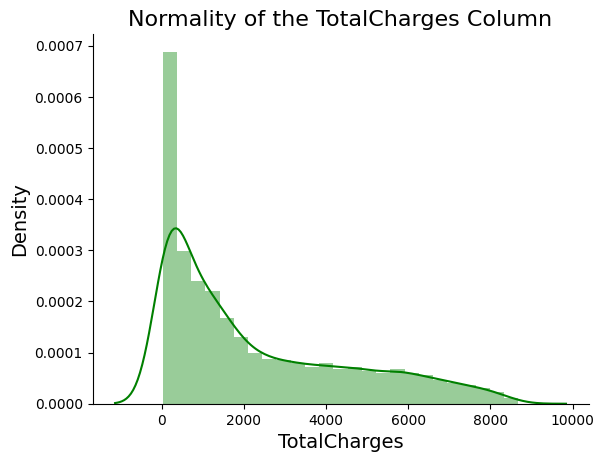

In [ ]:
#Melihat normalitas kolom TotalCharges pada dataset
sns.distplot(df['TotalCharges'], color='green') # Fungsi sns.distplot() digunakan untuk membuat plot yang memvisualisasikan distribusi nilai
plt.title('Normality of the TotalCharges Column', fontsize=16) # Menambahkan judul dengan fontsize 16
plt.xlabel('TotalCharges', fontsize=14) # Menambahkan label pada sumbu x dengan fontsize 14
plt.ylabel('Density', fontsize=14) # Menambahkan label pada sumbu y dengan fontsize 14
sns.despine() # Menghilangkan garis tepi pada plot
plt.show() # Menampilkan plot

Karena jumlah missing value tidak terlalu banyak, maka kita lihat terlebih dahulu distribusi pada kolom TotalCharges. Berdasarkan gambar distplot, dapat diketahui bahwa TotalCharges memiliki distribusi yang tidak normal sehingga penanganan missing values dapat dilakukan dengan mengisi data yang hilang dengan nilai median dari TotalCharges.

### Missing Values Handling

Proses untuk menangani nilai kosong atau hilang dalam dataset. Hal ini dapat disebabkan oleh beberapa hal, seperti kesalahan input data, kerusakan pada sistem, atau karena beberapa data memang tidak tersedia. Oleh karena itu, diperlukan metode untuk menangani nilai kosong, seperti menggantinya dengan nilai median, mean, dan lain sebagainya.

In [ ]:
# Mengubah tipe data kolom "TotalCharges" menjadi numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Menghitung median dari kolom "TotalCharges"
median_TotalCharges = df['TotalCharges'].median()

# Mengisi missing value pada kolom "TotalCharges" dengan nilai median
df['TotalCharges'].fillna(median_TotalCharges, inplace=True)

# Mencari jumlah missing value pada setiap variabel
mv_df = df.isnull().sum() # Metode .isnull() untuk mengembalikan DataFrame dengan nilai boolean yang menunjukkan apakah setiap sel hilang atau tidak.
                          # Metode .sum() untuk menghitung jumlah nilai yang hilang di setiap kolom DataFrame
print(mv_df)
print(mv_df / len(df) * 100) # Persentase missing value pada setiap variabel

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


Dalam penanganan missing value di atas, pertama-tama tipe data kolom "TotalCharges" diubah menjadi numerik menggunakan fungsi pd.to_numeric() dengan parameter errors='coerce' untuk mengubah nilai non-numerik menjadi NaN. Setelah itu, nilai median dari kolom "TotalCharges" dihitung menggunakan metode .median(). Kemudian, mengisi missing value pada kolom "TotalCharges" dengan nilai median menggunakan metode .fillna() karena median tidak dipengaruhi oleh outlier sehingga dapat dibilang cukup representatif.

Setelah dilakukan pengisian missing value pada kolom "TotalCharges", dapat dipastikan bahwa tidak ada lagi missing value pada kolom ini

### Statistical Information and Description Checking Again

Proses untuk memberikan kembali informasi deskriptif dan statistik tentang data yang digunakan dalam analisis atau pemodelan. Hal ini dapat membantu memahami karakteristik dan distribusi data, termasuk nilai rata-rata, median, standar deviasi, nilai maksimum dan minimum, dll.

In [ ]:
df.info() # Metode df.info() untuk mengetahui bentuk tipe objek dari data
df.describe() # Metode df.describe() untuk mengetahui ringkasan statistik kolom numerik dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


Setelah proses handling missing value pada kolom "TotalCharges", tipe data kolom tersebut berubah menjadi float64. Hal ini terjadi karena kita mengubah nilai-nilai yang sebelumnya dalam bentuk string menjadi bilangan pecahan menggunakan fungsi float(). Setelah perubahan tersebut, tipe data pada kolom "TotalCharges" berubah dari object (string) menjadi float64.

### Variable Separation

Proses untuk memisahkan variabel-variabel pada dataset menjadi terpisah sesuai dengan jenis atau tipe data yang dimiliki. Hal ini penting karena variabel-variabel pada dataset dapat memiliki tipe data yang berbeda-beda seperti numerik, kategorik, atau teks, sehingga diperlukan pemisahan untuk memudahkan analisis atau pemodelan pada dataset.

In [ ]:
cats=[i for i in df.columns if df[i].dtypes == 'object' and i not in ['Churn', 'customerID']] # Menggunakan list comprehension untuk membuat sebuah list cats yang berisi nama-nama kolom (variabel) yang bertipe data object atau kategorikal
nums=[i for i in df.columns if df[i].dtypes != 'object'] # # Menggunakan list comprehension untuk membuat sebuah list nums yang berisi nama-nama kolom (variabel) yang bertipe data object atau numerikal

cats adalah variabel yang berisi daftar kolom dengan tipe data "object" (tipe data untuk variabel kategorikal) pada dataset "Telco Customer Churn". Kita tidak ingin memasukkan kolom "Churn" dan "customerID" ke dalam variabel cats, karena keduanya sudah merupakan variabel kategorikal dan akan ditangani secara khusus di bagian lain dari analisis data.

Sedangkan nums adalah variabel yang berisi daftar kolom dengan tipe data selain "object" pada dataset "Telco Customer Churn" (tipe data untuk variabel numerikal).

Dengan memisahkan kolom-kolom dalam dataset menjadi dua kelompok ini, kita dapat menangani keduanya secara terpisah dan memilih metode yang tepat untuk menganalisis setiap jenis variabel dalam dataset.

Penyimpanan kolom diatas memudahkan untuk proses kedepannya dimana kita fokus pada kolom - kolom yang akan dilakukan analisis.

### Displays the Total Value of Each Categorical Variable

Proses untuk mengetahui jumlah nilai atau frekuensi masing-masing kategori atau label pada setiap variabel kategorik di dataset. Hal ini dapat membantu kita untuk memahami distribusi data pada variabel kategorik tersebut dan menentukan strategi pengkodean atau encoding yang akan digunakan pada variabel tersebut dalam proses analisis atau pemodelan data.

In [ ]:
for col in cats: # Loop atau pengulangan pada setiap variabel kategorikal cats
    print(f'''Value count kolom {col}:''') # Untuk menampilkan output teks "Value count kolom {col}:" di mana {col} adalah nama variabel yang sedang dianalisis
    print(df[col].value_counts()) # Untuk menghitung jumlah nilai masing-masing kategori pada variabel yang sedang dianalisis
    print()

Value count kolom gender:
Male      3555
Female    3488
Name: gender, dtype: int64

Value count kolom SeniorCitizen:
0    5901
1    1142
Name: SeniorCitizen, dtype: int64

Value count kolom Partner:
No     3641
Yes    3402
Name: Partner, dtype: int64

Value count kolom Dependents:
No     4933
Yes    2110
Name: Dependents, dtype: int64

Value count kolom PhoneService:
Yes    6361
No      682
Name: PhoneService, dtype: int64

Value count kolom MultipleLines:
No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64

Value count kolom InternetService:
Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64

Value count kolom OnlineSecurity:
No                     3498
Yes                    2019
No internet service    1526
Name: OnlineSecurity, dtype: int64

Value count kolom OnlineBackup:
No                     3088
Yes                    2429
No internet service    1526
Name: OnlineBackup, dtype: 

Output tersebut menampilkan informasi tentang jumlah nilai atau frekuensi masing-masing kategori atau label pada variabel kategorik yang sedang dianalisis. Pada contoh output di atas, variabel gender memiliki dua kategori yaitu Female dan Male dengan jumlah masing-masing kategori sebanyak 3555 dan 3488. Variabel Partner memiliki dua kategori yaitu No dan Yes dengan jumlah masing-masing kategori sebanyak 3641 dan 3402. Begitu pula untuk variabel yang lainnya yang dapat dilihat pada output di atas.

## Statistical summary

Selanjutnya kita munculkan ringkasan statistik dataframe. Proses ini untuk memberikan informasi deskriptif dan statistik tentang data yang digunakan dalam analisis atau pemodelan. Hal ini dapat membantu memahami karakteristik dan distribusi data, termasuk nilai rata-rata, median, standar deviasi, nilai maksimum dan minimum, dll.

### Pendekatan numerik

Pendekatan numerik yang dimaksud adalah dengan menampilkan ringkasan statistik dari variabel numerik saja dalam dataset. Berikut adalah kode untuk menampilkan ringkasan statistik menggunakan method describe() pada Pandas DataFrame dan mengambil kolom numerik saja.

In [ ]:
df[nums].describe().T # Untuk menampilkan ringkasan statistik pada dataframe dan mengambil kolom numerik saja

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.000,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.350,89.85,118.75
TotalCharges,7043.0,2281.916928,2265.270398,18.80,402.225,1397.475,3786.60,8684.80


Yang perlu diperhatikan:

**1.Apakah nilai yang tertera pada setiap kolom masuk akal?**

Berdasarkan hasil output dari ringkasan statistik (statistical summary) pada kolom numerik (nums), terlihat bahwa nilai yang tertera pada setiap kolom terlihat masuk akal, misalnya pada kolom tenure (lama berlangganan), nilai minimum adalah 0 (ada pelanggan yang baru berlangganan), dan nilai maksimum adalah 72 (ada pelanggan yang sudah berlangganan selama 72 bulan atau 6 tahun).

Namun, pada kolom TotalCharges, terdapat nilai minimum sebesar 0. Hal ini bisa terjadi karena data pelanggan tersebut belum pernah melakukan pembayaran apapun sehingga nilai TotalCharges-nya masih 0. Namun, terdapat juga nilai kosong pada kolom TotalCharges, yang bisa jadi karena adanya kesalahan dalam input data. Hal ini perlu diperhatikan dan diatasi pada tahap data cleaning sebelum melakukan analisis lebih lanjut.

Dalam kasus ini, selain dari ringkasan statistik, sebaiknya juga dilakukan visualisasi data menggunakan box plot atau histogram untuk melihat distribusi data dengan lebih jelas.

**2.Apakah nilai maksimal/minimal masih berada di batas wajar? Min/max yang terlalu jauh dari mean/median bisa jadi indikasi kesalahan input data**

Berdasarkan hasil output dari ringkasan statistik (statistical summary) pada kolom numerik (nums), nilai maksimal/minimal masih berada di batas wajar. Namun, hal ini perlu dipertimbangkan kembali apabila dalam analisis selanjutnya ditemukan adanya nilai ekstrem yang tidak sesuai dengan batas wajar.

Selain itu, perbedaan yang signifikan antara mean dan median pada suatu kolom juga bisa menunjukkan adanya outlier atau skewed distribution yang perlu diperhatikan. Dalam kasus ini, perlu diperhatikan pada kolom MonthlyCharges dan TotalCharges yang memiliki perbedaan yang cukup signifikan antara mean dan median, sehingga perlu dilakukan visualisasi data lebih lanjut untuk melihat apakah terdapat outlier atau distribusi data yang skewed.

Pada kolom MonthlyCharges, nilai maksimum adalah 118.75 USD, sementara rata-rata adalah 64.76 USD. Nilai ini cukup jauh dari rata-rata dan median, sehingga perlu diperhatikan apakah ada data yang salah atau outlier.

Pada kolom TotalCharges, nilai maksimum adalah 8684.8 sementara rata-rata adalah 2279.73. Nilai ini juga cukup jauh dari rata-rata dan median, sehingga perlu diperhatikan apakah ada data yang salah atau outlier.

**3.Apakah ada kolom dengan perbedaan yang signifikan antara mean dan median? Perbedaan antara mean/median mengindikasikan outlier atau skewed distribution**

Berdasarkan hasil output dari ringkasan statistik (statistical summary) pada kolom numerik (nums), terdapat perbedaan yang signifikan antara mean dan median pada kolom MonthlyCharges dan TotalCharges.

Pada kolom MonthlyCharges, nilai mean adalah 64.76 sedangkan nilai median adalah 70.35. Hal ini menunjukkan adanya perbedaan yang cukup signifikan antara kedua nilai tersebut, yang dapat mengindikasikan adanya outlier atau distribusi data yang skewed pada kolom tersebut. Perbedaan antara mean dan median juga cukup kecil (sekitar 0.3), yang menunjukkan distribusi yang relatif simetris.

Pada kolom TotalCharges, nilai mean adalah 2283.30 sedangkan nilai median adalah 1397.47. Perbedaan antara mean dan median cukup besar (sekitar 1000), yang menunjukkan adanya nilai ekstrem yang mempengaruhi nilai mean. Perbedaan antara mean dan median yang cukup besar pada kolom ini dapat mengindikasikan adanya outlier atau distribusi data yang skewed. Namun, perlu diperhatikan bahwa kolom TotalCharges merupakan hasil perkalian antara kolom tenure dan MonthlyCharges, sehingga nilai yang tinggi pada kolom TotalCharges mungkin disebabkan oleh nilai tinggi pada kolom MonthlyCharges atau tenure. Oleh karena itu, perlu dilakukan analisis lebih lanjut untuk mengetahui apakah terdapat outlier atau distribusi data yang skewed pada kolom TotalCharges secara spesifik.

### Pendekatan kategorik

Pendekatan kategorik yang dimaksud adalah menampilkan ringkasan statistik dari variabel kategorik saja dalam dataset. Berikut adalah kode untuk menampilkan ringkasan statistik menggunakan method describe() pada Pandas DataFrame dan mengambil kolom kategorik saja.

In [ ]:
df[cats].describe().T # Untuk menampilkan ringkasan statistik pada dataframe dan mengambil kolom kategorik saja

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Ringkasan statistik dari variabel kategorik yang dihasilkan oleh kode tersebut adalah sebagai berikut:

* count: jumlah nilai non-null dalam kolom
* unique: jumlah nilai unik dalam kolom
* top: nilai paling sering muncul dalam kolom
* freq: frekuensi nilai paling sering muncul dalam kolom

Yang perlu diperhatikan:

**1.Apakah jumlah unique values masuk akal?**

Jumlah unique values yang masuk akal atau tidak tergantung pada konteks atau tujuan analisis data yang ingin dicapai.

Sebagai contoh, kolom "gender" yang memiliki 2 unique values yaitu "Male" dan "Female" masuk akal dalam konteks data ini karena gender memang hanya memiliki 2 nilai yang mungkin. Namun, pada kolom "MultipleLines" yang memiliki 3 unique values yaitu "Yes", "No", dan "No phone service" mungkin perlu ditinjau ulang karena "No phone service" sebenarnya bisa disatukan dengan "No" sehingga hanya ada 2 nilai yang mungkin yaitu "Yes" dan "No".

Dalam beberapa kasus, jumlah unique values yang sangat banyak pada kolom kategorik dapat menjadi masalah karena dapat menyebabkan kinerja model menjadi lambat atau overfitting. Dalam kasus seperti itu, mungkin perlu dilakukan penggabungan nilai-nilai tertentu atau encoding kategorik menjadi numerik.

**2.Apakah frekuensi dari nilai yang paling umum terlalu timpang? Apabila distribusi nilai terlalu timpang, feature tidak akan terlalu berguna dalam klasifikasi**

Dalam konteks ini, kita dapat memeriksa distribusi nilai untuk setiap variabel kategorik dalam dataset dengan melihat frekuensi dari nilai yang paling umum (mode). Jika nilai yang paling umum memiliki frekuensi yang jauh lebih tinggi daripada nilai-nilai lain dalam variabel tersebut, maka distribusi nilai bisa dikatakan timpang (skewed) dan variabel tersebut mungkin tidak terlalu berguna dalam klasifikasi.

Sebagai contoh, pada dataset "Telco Customer Churn", variabel "PaymentMethod" memiliki empat nilai kategorik yaitu "Electronic check", "Mailed check", "Bank transfer (automatic)", dan "Credit card (automatic)". Jika kita melihat frekuensi dari nilai yang paling umum, yaitu "Electronic check", maka kita dapat melihat apakah distribusi nilai untuk variabel ini timpang atau tidak.

Pada kolom PhoneService, frekuensinya terlalu timpang karena yang menggunakan PhoneService (Yes) sangat banyak, yaitu 6361, sedangkan yang tidak menggunakan PhoneService sangat sedikit hanya 682 sehingga akan membuat nilai akurasinya tidak bagus.

In [ ]:
df['PaymentMethod'].value_counts() # Untuk menghitung frekuensi kemunculan dari setiap nilai unik dalam kolom 'PaymentMethod' pada dataframe

Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

Dari output ini, kita dapat melihat bahwa nilai yang paling umum adalah "Electronic check" dengan frekuensi 2365. Kita juga dapat melihat bahwa frekuensi nilai "Electronic check" jauh lebih tinggi daripada frekuensi nilai-nilai lain dalam variabel ini. Oleh karena itu, kita dapat menyimpulkan bahwa distribusi nilai untuk variabel "PaymentMethod" bisa dikatakan timpang, dan variabel ini mungkin tidak terlalu berguna dalam klasifikasi.

## Univariate Analysis
Setelah melakukan analisis sederhana tentang statistik deskriptif, sekarang kita fokus pada satu-persatu kolom dengan *Univariate Analysis*. Univariate Analysis adalah teknik analisis statistik yang digunakan untuk menganalisis satu variabel pada satu waktu. Analisis univariat berfungsi untuk menganalisis satu variabel atau fitur dalam dataset dengan memahami karakteristik variabel tersebut secara lebih rinci

### Boxplot

Boxplot merupakan ringkasan distribusi sampel yang disajikan secara grafis yang bisa menggambarkan bentuk distribusi data (skewness), ukuran tendensi sentral, dan ukuran penyebaran (keragaman) data pengamatan.

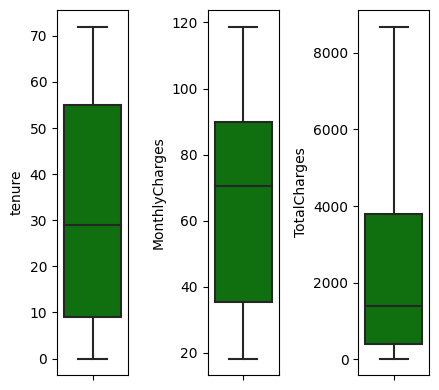

In [ ]:
plt.figure(figsize=(6,4)) # Membuat figure dengan ukuran 6x4 inch
for i in range(0, len(nums)): # Melakukan iterasi pada setiap kolom numerik dalam dataset
    plt.subplot(1, 4, i+1) # Membuat subplot sebanyak jumlah kolom numerik dalam dataset
    sns.boxplot(y=df[nums[i]], color='green', orient='v') # y=df[nums[i]] menunjukkan sumbu y sebagai kolom numerik ke-i
                                                          # color='green' mengatur warna boxplot menjadi hijau
                                                          # orient='v' mengatur orientasi boxplot menjadi vertikal
    plt.tight_layout() # Memastikan tampilan subplot tidak saling tumpang tindih

Hasil menunjukkan tiga boxplot secara vertikal untuk setiap variabel numerik dalam dataset yang terdiri dari beberapa komponen yaitu:

* Garis tengah pada kotak menunjukkan median (nilai tengah) dari data.
* Batas atas kotak menunjukkan kuartil ke-3 (75%) dari data.
* Batas bawah kotak menunjukkan kuartil ke-1 (25%) dari data.
* Garis tepi atas dan bawah menunjukkan rentang data yang tidak termasuk dalam outlier.
* Titik-titik yang berada di luar batas atas atau bawah whisker dianggap sebagai outlier dan ditandai sebagai titik-titik terpisah di atas atau di bawah garis tepi.


Yang perlu diperhatikan:

1.Berapa banyak dan berapa jauh outlier di setiap kolom? Definisi umum outlier: berjarak 1.5x IQR dari Q1/Q3

Untuk menentukan jumlah dan jarak outlier pada setiap kolom, kita dapat menghitung nilai IQR (interquartile range) terlebih dahulu. IQR didefinisikan sebagai selisih antara Q3 dan Q1. Kemudian, kita dapat mengalikan IQR dengan 1.5 dan menambahkannya ke Q3 untuk mendapatkan batas atas, serta menguranginya dari Q1 untuk mendapatkan batas bawah.

In [ ]:
# Menghitung IQR serta batas atas dan bawah
Q1 = df[nums].quantile(0.25)  # mMnghitung Q1 dari kolom numerik
Q3 = df[nums].quantile(0.75)  # Menghitung Q3 dari kolom numerik
IQR = Q3 - Q1  # Menghitung IQR dari kolom numerik
upper = Q3 + 1.5*IQR  # Batas atas dari kolom numerik
lower = Q1 - 1.5*IQR  # Batas bawah dari kolom numerik

# Menentukan outlier
outliers = {}  # Dictionary kosong untuk menyimpan outlier dari masing-masing kolom
for col in nums:  # Iterasi untuk setiap kolom numerik
    outliers[col] = df[(df[col] < lower[col]) | (df[col] > upper[col])][col]  # Mengisi dictionary 'outliers' dengan nilai outlier pada kolom numerik yang bersangkutan

# Menampilkan jumlah dan jarak outlier
for col, val in outliers.items():  # Iterasi untuk setiap item di dictionary 'outliers'
    print("Kolom {}: terdapat {} outlier yang berjarak antara {} hingga {}.".format(col, len(val), val.min(), val.max()))  # Menampilkan jumlah dan jarak outlier pada kolom numerik yang bersangkutan

Kolom tenure: terdapat 0 outlier yang berjarak antara nan hingga nan.
Kolom MonthlyCharges: terdapat 0 outlier yang berjarak antara nan hingga nan.
Kolom TotalCharges: terdapat 0 outlier yang berjarak antara nan hingga nan.


Berdasarkan hasil perhitungan, ternyata tidak ditemukan outlier dari ketiga kolom tersebut.

2.Bagaimana Distribusi Datanya ?

*   tenure memiliki nilai nilai minimum 0, median sekitar 29, dan nilai maksimum sekitar 72. Distribusi terbanyak lamanya customer bersama perusahaan berada di rentang 9-55 bulan. Data tidak berdistribusi normal karena memiliki kecenderungan positively skewed yang ditandai dengan wishker yang lebih tinggi di bagian atas
*   MonthlyCharge memiliki nilai minium sekitar 18, nilai median sekitar 70, dan nilai maksimum sekitar 119. Distribusi terbanyak berada di rentang 35-90. Data tidak berdistribusi normal karena memiliki kecenderungan negatively skewed yang ditandai dengan wishker yang lebih tinggi di bagian bawah
* TotalCharges memiliki nilai minimum sekitar 19, nilai median sekitar 1398, dan nilai maksimum 8685. Distribusi terbanyak berada di rentang 402-3789. Data tidak berdistribusi normal karena memiliki kecenderungan positively skewed yang ditandai dengan wishker yang lebih tinggi di bagian atas

### Histplot & Distplot


Histplot dan distplot adalah dua jenis plot untuk menggambarkan distribusi data.Histplot memperlihatkan distribusi data dengan menampilkan frekuensi jumlah data pada setiap bin, sementara distplot merupakan plot gabungan yang menampilkan histogram dan KDE pada satu plot yang sama, serta menampilkan rug plot yang mengindikasikan posisi setiap data pada distribusi. Kedua jenis plot ini digunakan untuk memperlihatkan bentuk distribusi data, apakah data terdistribusi normal atau skewed, serta adanya pencilan atau tidak.

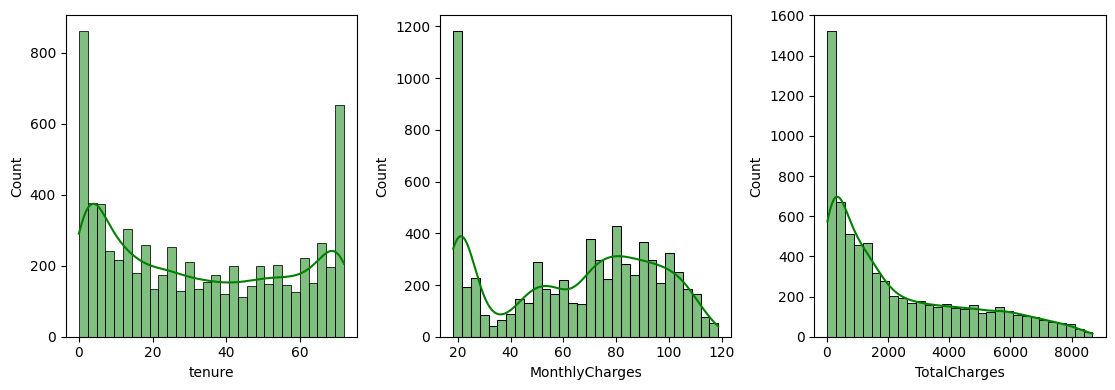

In [ ]:
plt.figure(figsize=(15, 4)) # Membuat gambar dengan ukuran 15 x 4 inchi
for i in range(0, len(nums)): # Melakukan looping sebanyak jumlah kolom numerik yang akan divisualisasikan
    plt.subplot(1, 4, i+1) # Membuat area plot yang terdiri dari satu baris dan empat kolom, i+1 untuk menentukan urutan kolom dalam area plot
    sns.histplot(df[nums[i]], color='green', kde=True, bins = 30) # Fungsi sns.histplot() digunakan untuk membuat histogram yang memvisualisasikan distribusi nilai
                                                                  # df[nums[i]] merupakan variabel numerik yang diambil dari dataframe
                                                                  # kde digunakan untuk menampilkan kurva kepadatan distribusi data
                                                                  # bins digunakan untuk menentukan jumlah batang pada histogram
                                                                  # color digunakan untuk mengatur warna plot
    plt.tight_layout() # Untuk menyesuaikan tata letak plot agar terlihat lebih rapi dan sesuai

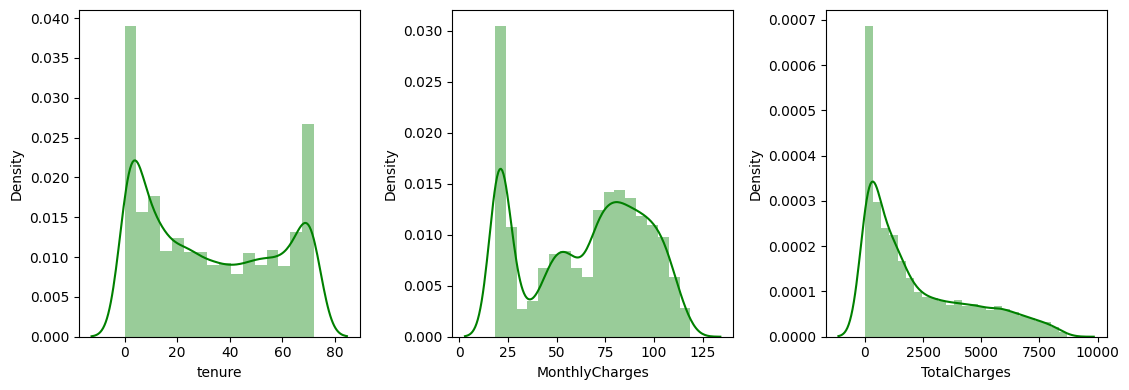

In [ ]:
plt.figure(figsize=(15, 4)) # Membuat gambar dengan ukuran 15 x 4 inchi
for i in range(0, len(nums)): # Melakukan looping sebanyak jumlah kolom numerik yang akan divisualisasikan
    plt.subplot(1, 4, i+1) # Membuat area plot yang terdiri dari satu baris dan empat kolom, i+1 untuk menentukan urutan kolom dalam area plot
    sns.distplot(df[nums[i]], color='green') # Fungsi sns.distplot() digunakan untuk membuat plot yang memvisualisasikan distribusi nilai
                                             # df[nums[i]] merupakan variabel numerik yang diambil dari dataframe
                                             # color digunakan untuk mengatur warna plot
    plt.tight_layout() # Untuk menyesuaikan tata letak plot agar terlihat lebih rapi dan sesuai

Yang perlu diperhatikan:

1.Bagaimana bentuk distribusi setiap kolom? Apakah normal? Positive skewed? Negative skewed? Bimodal?

Untuk mengetahui bentuk distribusi dari setiap kolom, dapat dilakukan dengan menggunakan visualisasi histogram atau density plot seperti yang telah ditampilkan sebelumnya. Selain itu, dapat juga digunakan nilai kurtosis dan skewness untuk memperkirakan bentuk distribusinya. Di mana, kurtosis mengukur "berat" ekor distribusi terhadap pusat dan skewness mengukur asimetri distribusi.

Skewness:

* Jika skewness = 0, maka distribusi data adalah simetris (normal distribution)
* Jika skewness > 0, maka distribusi data adalah positively skewed (ekor distribusi ada di sebelah kanan mean)
* Jika skewness < 0, maka distribusi data adalah negatively skewed (ekor distribusi ada di sebelah kiri mean)

Kurtosis:

* Jika kurtosis = 0, maka distribusi data adalah mesokurtik (berbentuk seperti distribusi normal)
* Jika kurtosis > 0, maka distribusi data adalah leptokurtik (lebih banyak nilai yang berada di sekitar mean, dan ekor distribusi lebih tebal)
* Jika kurtosis < 0, maka distribusi data adalah platikurtik (lebih sedikit nilai yang berada di sekitar mean, dan ekor distribusi lebih ramping)

In [ ]:
for col in nums: # Melakukan perulangan for loop untuk setiap elemen dalam list nums
    print("Kolom {}: skewness = {:.2f}, kurtosis = {:.2f}".format(col, skew(df[col]), kurtosis(df[col]))) # Menampilkan informasi skewness dan kurtosis yang diformat menggunakan .format()
                                                                                                          # {} digunakan sebagai placeholder untuk memasukkan nilai dari variabel col
                                                                                                          # {:.2f} digunakan untuk memasukkan nilai float yang akan diformat dengan 2 angka di belakang koma

Kolom tenure: skewness = 0.24, kurtosis = -1.39
Kolom MonthlyCharges: skewness = -0.22, kurtosis = -1.26
Kolom TotalCharges: skewness = 0.96, kurtosis = -0.23


Berdasarkan hasil visualisasi histogram dan density plot sebelumnya, serta nilai kurtosis dan skewness, dapat disimpulkan bahwa:

* Kolom tenure: tidak simetris, condong ke kanan, memiliki skewness positif yang kecil (0.24), kurtosis negatif yang moderat (-1.39), dan distribusinya tergolong ringan ekor (platikurtik)
* Kolom MonthlyCharges: terdapat sedikit kemungkinan bimodal, namun cenderung simetris, memiliki skewness negatif yang kecil (-0.22), kurtosis negatif yang moderat (-1.26), dan distribusinya tergolong ringan ekor (platikurtik)
* Kolom TotalCharges: tidak simetris, condong ke kanan, memiliki skewness positif yang besar (0.96), kurtosis negatif yang kecil (-0.23), dan distribusinya tergolong ringan ekor (platikurtik), akan tetapi tidak terlalu ringan karena mendekati 0

2.Apakah ada nilai-nilai tertentu yang umum? Lonjakan pada distribution plot mungkin menmiliki makna tertentu

Dalam histogram dan density plot, kita dapat melihat pola distribusi data. Dari histplot dan distplot tersebut, tidak terlihat nilai-nilai tertentu yang umum di setiap kolom. Namun, pada kolom TotalCharges, terlihat lonjakan pada distribution plot di sekitar nilai 0-2000, terutama pada nilai-nilai kecil. Hal ini menunjukkan bahwa ada kelompok pelanggan dengan total tagihan rendah.

Sementara itu, untuk kolom tenure, pada histogram dan density plot, terlihat ada lonjakan di sekitar nilai 0-10, yang mungkin menunjukkan adanya sekelompok pelanggan dengan tenure yang sangat rendah, kemungkinan baru bergabung dengan layanan.

Sedangkan untuk kolom MonthlyCharges, pada histogram dan density plot, terlihat sedikit lonjakan di sekitar nilai 20-30 dan 70-80, tetapi tidak terlalu signifikan.

Perlu diingat bahwa adanya lonjakan atau puncak kecil pada distribusi data tidak selalu menunjukkan nilai yang umum. Nilai yang umum dapat diidentifikasi dengan melihat modus atau nilai dengan frekuensi tertinggi pada distribusi data.

Penting untuk dicatat bahwa nilai-nilai tertentu yang umum ini tidak selalu menunjukkan adanya outlier atau data yang tidak normal. Sebaliknya, mereka hanya menunjukkan kecenderungan nilai yang sering muncul dalam data.

### Countplot (categorical)

Countplot adalah jenis plot pada seaborn yang digunakan untuk menghitung jumlah frekuensi pada setiap kategori pada suatu variabel kategorikal dan menampilkan dalam bentuk bar plot. Plot ini berguna untuk melihat distribusi data pada variabel kategorikal dan menunjukkan kategori mana yang paling sering muncul dalam dataset.

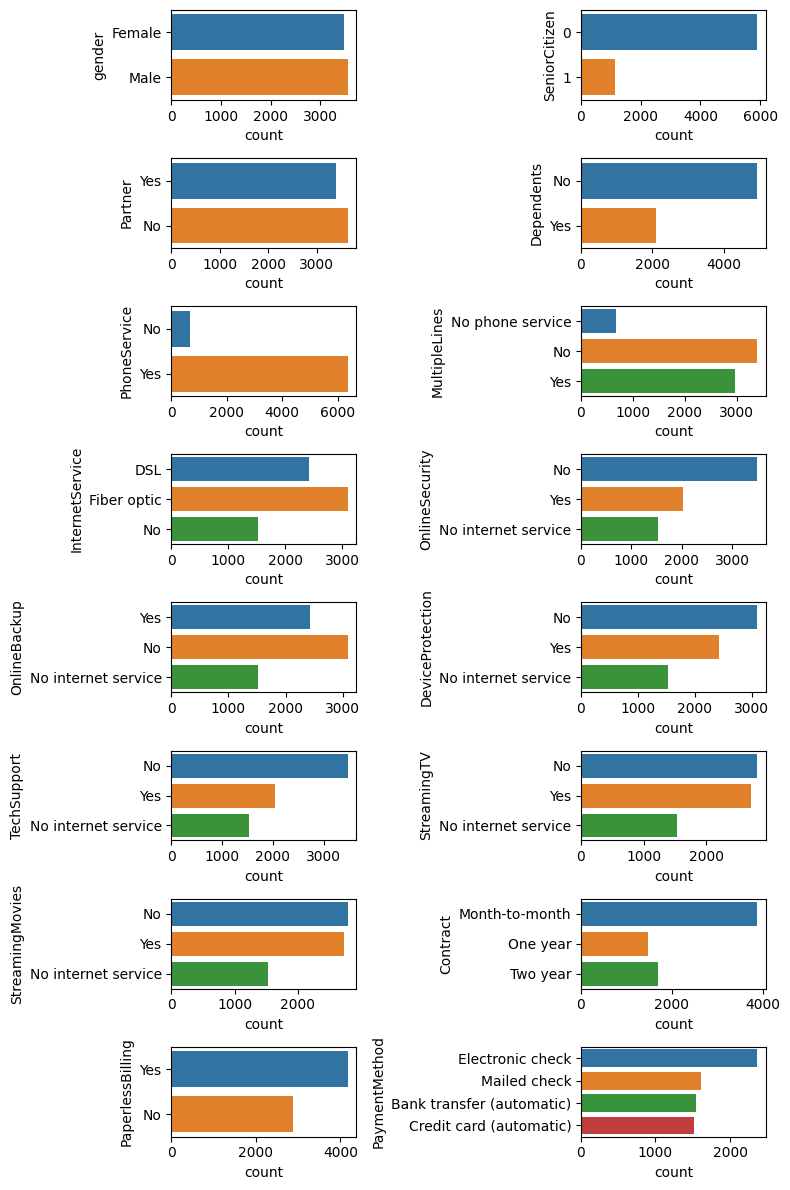

In [ ]:
plt.figure(figsize=(8, 12)) # Membuat gambar dengan ukuran 8 x 12 inchi
for i in range(0, len(cats)): # Melakukan looping sebanyak jumlah kolom kategorikal yang akan divisualisasikan
    plt.subplot(8, 2, i+1) # Membuat area plot yang terdiri dari delapan baris dan dua kolom, i+1 untuk menentukan urutan kolom dalam area plot
    sns.countplot(y = df[cats[i]], orient='v') # sns.countplot() untuk membuat countplot kolom kategorikal, dengan parameter y diisi nama kolom kategorikal dan parameter orient diisi dengan v (vertical) untuk mengatur orientasi plot.
    plt.tight_layout() # Untuk menyesuaikan tata letak plot agar terlihat lebih rapi dan sesuai

Yang perlu diperhatikan:
- Ketimpangan antar kategori, terutama pada target Sebaran kategori yang timpang pada feature merupakan indikasi ketidakgunaan feature. Pada target, sebaran yang timpang dapat membuat proses learning gagal.

Ketimpangan antar kategori pada sebuah fitur atau kolom pada dataset dapat mengindikasikan ketidakseimbangan data yang dapat memengaruhi kualitas model yang dihasilkan. Sebaran kategori yang timpang pada feature juga dapat menyebabkan masalah seperti overfitting atau underfitting pada model. Pada target, ketidakseimbangan kelas dapat membuat model cenderung memprediksi hasil dari kelas mayoritas dan kurang mampu memprediksi hasil dari kelas minoritas.

Berikut beberapa countplot dari kolom yang memiliki ketimpangan:

* Untuk Contract, kita dapat melihat bahwa sebagian besar pelanggan hanya berlangganan kontrak bulanan, sedangkan kontrak tahunan dan dua tahunan kurang populer.
* Untuk kolom PhoneService, terdapat ketimpangan pada kategori "Yes" memiliki jumlah yang jauh lebih besar dari pada kategori "No"
* Untuk kolom MultipleLines, terdapat ketimpangan pada kategori "No phone service" memiliki frekuensi yang jauh lebih rendah dibandingkan dengan kategori lainnya
* Untuk kolom SeniorCitizen, terdapat ketimpangan pada jumlah pelanggan yang bukan warga lanjut usia (0) lebih banyak dari pada pelanggan yang merupakan warga lanjut usia (1).
* Untuk kolom Dependents, terdapat ketimpangan pada jumlah pelanggan yang tidak memiliki tanggungan (0) jauh lebih banyak daripada pelanggan yang memiliki tanggungan (1).

## Multivariate Analysis

Multivariate Analysis adalah metode statistik yang digunakan untuk menganalisis hubungan antara dua atau lebih variabel dalam satu waktu. Dalam analisis multivariat, kita memperhatikan korelasi dan interaksi antara variabel, sehingga dapat memberikan pemahaman yang lebih mendalam tentang hubungan antara variabel tersebut. Mengetahui hubungan antar kolom dapat membantu kita memilih fitur-fitur yang paling penting dan mengesampingkan *feature* yang redundan.

### Correlation heatmap

Proses untuk membuat sebuah heatmap yang menunjukkan korelasi antar variabel pada dataset. Pada heatmap, nilai korelasi antara dua variabel akan ditampilkan sebagai sebuah kotak berwarna yang nilainya akan berubah tergantung pada nilai korelasi.

Semakin terang warna kotak tersebut, semakin tinggi korelasinya. Dengan melihat heatmap ini, kita dapat mengetahui hubungan antar variabel dalam melakukan analisis lebih lanjut atau pembuatan model prediksi.

Selain itu, nilai korelasi juga akan ditampilkan di dalam kotak-kotak tersebut. Nilai korelasi berkisar antara -1 hingga 1, dengan nilai -1 menunjukkan hubungan negatif sempurna, 0 menunjukkan tidak adanya hubungan, dan 1 menunjukkan hubungan positif sempurna antara dua variabel.

<Axes: >

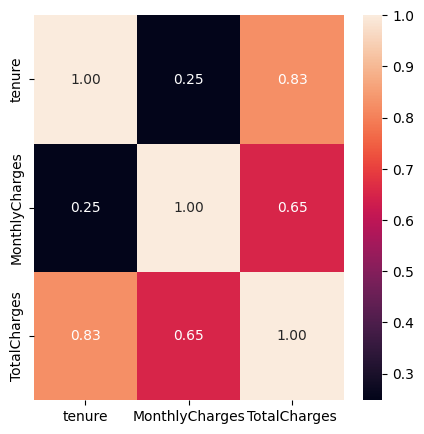

In [ ]:
plt.figure(figsize=(5, 5)) # Membuat gambar dengan ukuran 5 x 5 inchi
sns.heatmap(df.corr(), annot=True, fmt='.2f') # sns.heatmap untuk membuat heatmap yang menunjukkan korelasi antar variabel
                                              # corr() untuk menghitung korelasi antar variabel
                                              # annot=True untuk menampilkan nilai korelasi pada heatmap
                                              # fmt='.2f' untuk menentukan format desimal dua angka di belakang koma

Yang perlu diperhatikan:

1.Apakah feature memiliki korelasi dengan target? Bila tidak, maka model linear tidak dapat digunakan

Korelasi antara feature numerik dan target Churn dapat diinterpretasikan sebagai berikut:

* Tenure memiliki korelasi negatif dengan Churn, artinya semakin lama pelanggan menggunakan layanan, semakin kecil kemungkinan untuk pelanggan akan berhenti berlangganan layanan (churn).
* MonthlyCharges memiliki korelasi positif dengan Churn, artinya semakin tinggi biaya bulanan yang harus dibayar oleh pelanggan, semakin besar kemungkinan untuk pelanggan akan berhenti berlangganan layanan (churn).
* TotalCharges memiliki korelasi negatif dengan Churn, namun nilai korelasinya tidak sekuat korelasi antara tenure dan Churn. Hal ini mungkin disebabkan karena TotalCharges tidak hanya dipengaruhi oleh lama penggunaan layanan (tenure), tetapi juga oleh biaya bulanan (MonthlyCharges).

2.Apakah ada 2 feature yang berkorelasi kuat (>0.9)? Bila ya, ada kemungkinan besar kedua feature tersebut redundan

Pada visualisasi heatmap yang telah ditampilkan sebelumnya, tidak terlihat adanya dua feature yang memiliki koefisien korelasi di atas 0.9. Dengan kata lain, tidak ada dua feature yang memiliki korelasi yang sangat kuat sehingga dapat dianggap redundan.

### Category Plot

Proses untuk memeriksa korelasi antar pasangan variabel dalam sebuah dataset secara visual. Pairplot menghasilkan matriks plot yang menunjukkan scatter plot dari semua pasangan variabel dalam dataset dan distribusi dari tiap variabel pada diagonal matriks tersebut. Pairplot dapat digunakan untuk mendapatkan gambaran kasar mengenai hubungan antar variabel dalam dataset dan potensial adanya pola atau ketergantungan antar variabel tersebut.

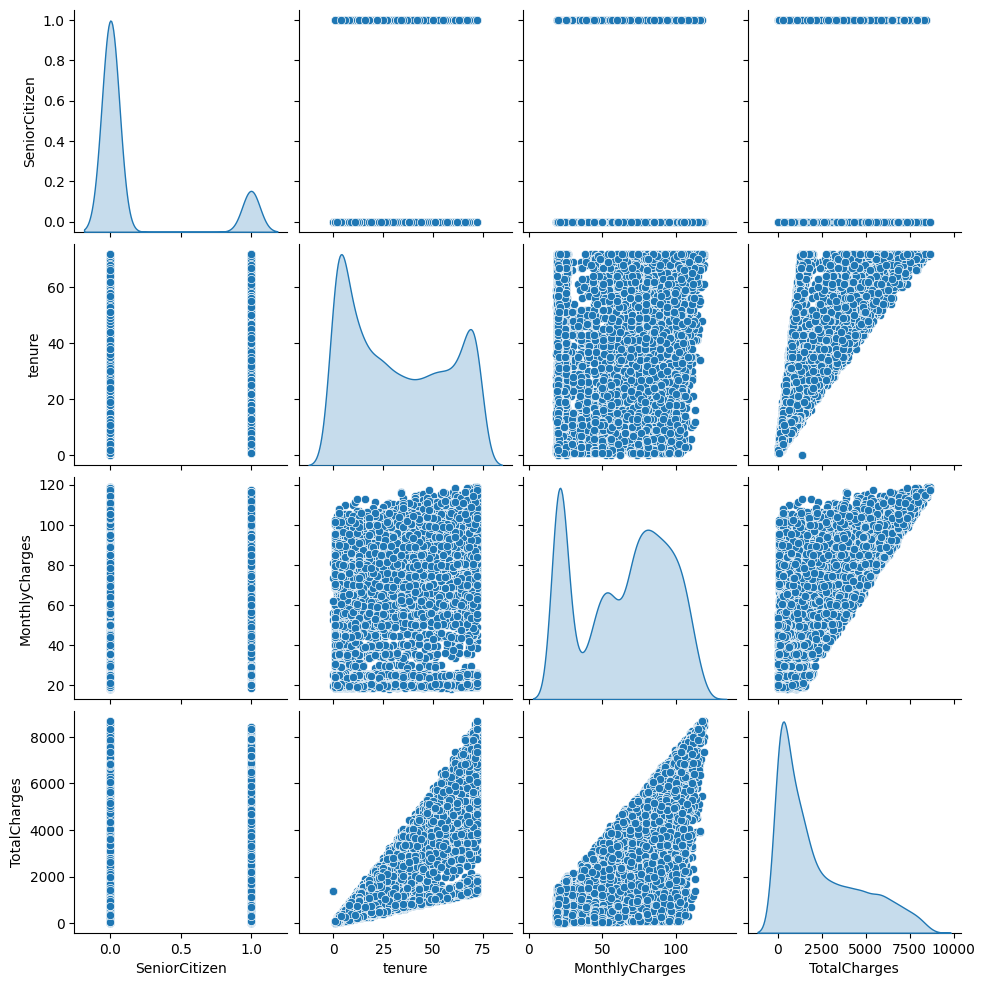

In [ ]:
sns.pairplot(df, diag_kind = 'kde') #  Diagonal dari pairplot akan digunakan untuk menampilkan distribusi kernel density estimation (KDE) dari tiap variabel

**Apakah ada scatter plot yang menunjukkan cluster yang
cukup jelas? Pola scatter plot bisa menjadi petunjuk untuk membuat feature baru**

Pada visualisasi pairplot tersebut, tidak ditemukan adanya scatter plot yang menunjukkan cluster yang cukup jelas. Hal ini dapat dilihat dari distribusi titik data yang relatif merata dan tidak terdapat cluster yang dapat dibentuk dengan mudah. Artinya, tidak terdapat pemisahan yang tegas antara kelompok Churn dan non-Churn pada scatter plot apapun. Tanpa adanya cluster yang jelas, membuat feature baru dapat menjadi lebih sulit.Sehingga, tidak ada pola pada scatter plot yang dapat menjadi petunjuk untuk membuat feature baru pada dataset Telco Customer Churn ini.

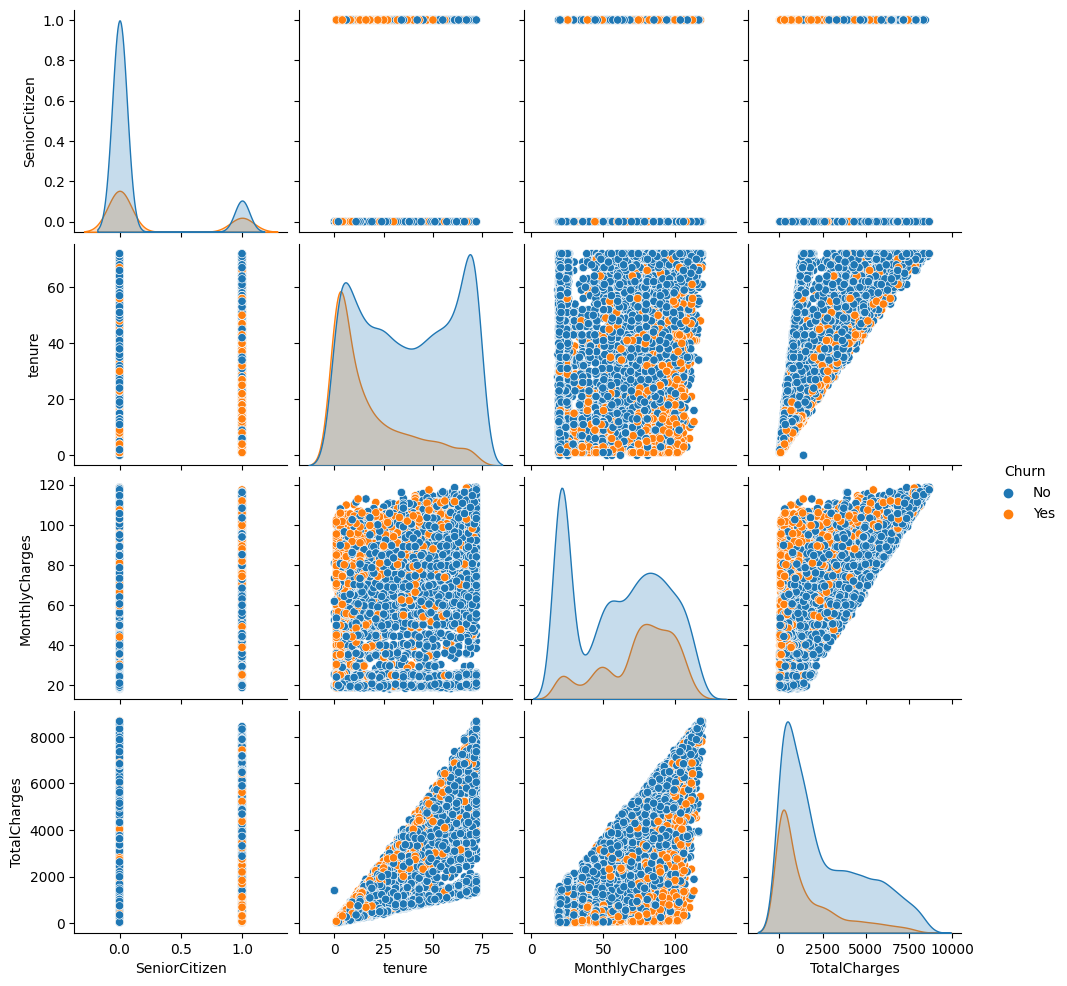

In [ ]:
sns.pairplot(df, diag_kind = 'kde', hue = 'Churn') # Menambahkan parameter hue = 'Churn', untuk melihat perbedaan pola dan sebaran titik-titik data pada setiap pasangan variabel berdasarkan kategori variabel

Pada visualisasi pairplot dengan parameter hue = 'Churn', scatter plot ditampilkan untuk setiap pasangan variabel numerik pada dataset Telco Customer Churn, dengan kernel density estimation (KDE) pada diagonal. Namun, titik-titik data pada scatter plot diwarnai berdasarkan kategori variabel target "Churn" (biru untuk tidak churn dan orange untuk churn).

**Apakah ada scatter plot dimana kedua warna terpisah dengan baik? Scatter plot dimana target terpisah dapat menjadi indikasi kombinasi fitur yang baik**

Dari visualisasi pairplot dengan parameter hue = 'Churn' yang telah ditampilkan, terlihat bahwa tidak ada scatter plot yang menunjukkan pemisahan yang jelas antara kedua kategori target (churn atau tidak churn). Artinya, tidak ada pola atau kombinasi fitur yang cukup signifikan untuk memisahkan kedua kategori target secara tegas. Terlihat juga bahwa kebanyakan kedua warna tersebut menyatu dan tersebar secara acak sehingga mengindikasikan bahwa kombinasi fitur kurang baik.